In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb  
import xgboost as xgb
import catboost as cb

In [5]:
TRAIN_DATA_PATH = os.path.join("data", "train")
TEST_DATA_PATH = os.path.join("data", "test")

def load_data():
    train_df = pd.read_csv(os.path.join(TRAIN_DATA_PATH, "train.csv"))
    train_add=pd.read_csv(os.path.join(TRAIN_DATA_PATH, "train_add.csv"))

    train_stadium=pd.read_csv(os.path.join(TRAIN_DATA_PATH, "stadium.csv"))
    train_stadium = train_stadium.rename(columns={"name": "stadium"})
    train_stadium = train_stadium[["stadium", "capa"]]
    train_condidion=pd.read_csv(os.path.join(TRAIN_DATA_PATH, "condition.csv"))
    train_condidion_add=pd.read_csv(os.path.join(TRAIN_DATA_PATH, "condition_add.csv"))
    train_condidion = train_condidion[['id', 'weather', 'temperature', 'humidity']]
    train_df = pd.concat([train_df, train_add], axis=0, ignore_index=True)
   
    train_condidion = pd.concat([train_condidion, train_condidion_add], axis=0, ignore_index=True)
    train_df = pd.merge(train_df, train_condidion, on='id', how="left")
    train_df = pd.merge(train_df, train_stadium, on='stadium', how="left")
    test_df = pd.read_csv(os.path.join(TEST_DATA_PATH, "test.csv"))
    test_df = pd.merge(test_df, train_condidion, on='id', how="left")
    test_df = pd.merge(test_df, train_stadium, on='stadium', how="left")
    return train_df, test_df

train_df, test_df = load_data()

In [ ]:
## 前処理関数のモジュール化
 # 追加したい処理は関数を定義して PREPROCESSING_STEPS に追加する

def add_section(df: pd.DataFrame) -> pd.DataFrame:
    """節（section）番号を抽出"""
    df['section'] = df['match'].apply(lambda x: x.split('節')[0][1:]).astype(int)
    return df

def add_month(df: pd.DataFrame) -> pd.DataFrame:
    """月を抽出"""
    df['month'] = df['gameday'].apply(lambda x: x[:2]).astype(int)
    return df

def add_weekday(df: pd.DataFrame) -> pd.DataFrame:
    """曜日を抽出"""
    df['weekday'] = df['gameday'].apply(lambda x: x[6])
    return df

def add_is_saturday(df: pd.DataFrame) -> pd.DataFrame:
    """土曜日フラグを追加"""
    df['is_saturday'] = df['weekday'].apply(lambda x: 1 if x == '土' else 0)
    return df

def add_hour(df: pd.DataFrame) -> pd.DataFrame:
    """試合開始時間（時）を抽出"""
    df['hour'] = df['time'].apply(lambda x: x.split(':')[0]).astype(int)
    return df

def add_num_tv(df: pd.DataFrame) -> pd.DataFrame:
    """TV放送局数を算出"""
    df['num_tv'] = df['tv'].apply(lambda x: len(x.split('／')))
    return df


# --- 前処理パイプライン ---
# 新しい前処理を追加する場合はリストに関数を追加する
PREPROCESSING_STEPS = [
    add_section,
    add_month,
    add_weekday,
    add_is_saturday,
    add_hour,
    add_num_tv,
]

def apply_preprocessing(df: pd.DataFrame, steps: list = None) -> pd.DataFrame:
    """前処理パイプラインを順番に適用する"""
    if steps is None:
        steps = PREPROCESSING_STEPS
    for step in steps:
        df = step(df)
    return df

# 前処理の適用
train_df = apply_preprocessing(train_df)
test_df = apply_preprocessing(test_df)

print(f"前処理完了: train={train_df.shape}, test={test_df.shape}")
print(f"適用した前処理ステップ数: {len(PREPROCESSING_STEPS)}")

/tmp/ipykernel_153901/2239402330.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.select_dtypes(include=object).head()


In [ ]:
# 使用する特徴量を選択（前処理で追加した列から選ぶ）
use_columns = ['capa', 'section', 'stage', 'month', 'hour', 'num_tv', 'is_saturday']

# 目的変数をlog変換
y = np.log1p(train_df['y'])
train = train_df[use_columns]
test = test_df[use_columns]

print(f"使用する特徴量: {use_columns}")
print(f"train: {train.shape}, test: {test.shape}")
print(f"y (log1p変換済み): min={y.min():.3f}, max={y.max():.3f}")

In [16]:
# カテゴリ変数のエンコード
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)
X_train, X_valid, y_train, y_valid = train_test_split(train, y, random_state = 82)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(1464, 7) (489, 7) (1464,) (489,)


In [17]:
rfr = RandomForestRegressor(random_state=82)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# 予測・精度評価（逆変換して元スケールのRMSEを算出）
y_pred_train = rfr.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_pred_train)))

y_pred_valid = rfr.predict(X_valid)
rmse_valid = np.sqrt(mean_squared_error(np.expm1(y_valid), np.expm1(y_pred_valid)))

print('学習データの予測精度 (RMSE)', rmse_train)
print('評価データの予測精度 (RMSE)', rmse_valid)

学習データの予測精度 1446.777742722987
評価データの予測精度 3964.681242947356


/home/tetsuki/signate/j-league/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/tetsuki/signate/j-league/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32318 (\N{CJK UNIFIED IDEOGRAPH-7E3E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/tetsuki/signate/j-league/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/tetsuki/signate/j-league/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/tetsuki/signate/j-league/.venv/lib/python3.13/site-packages/IPytho

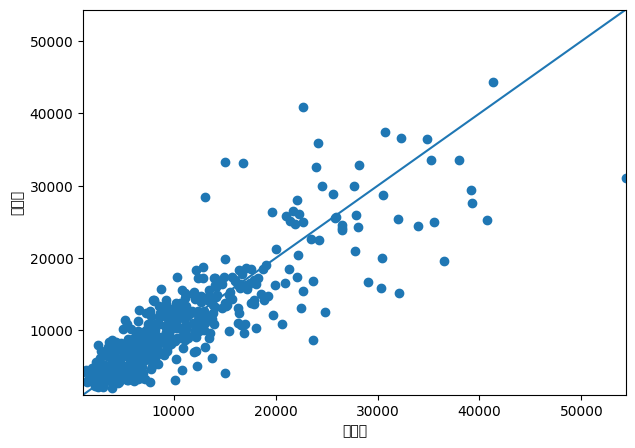

In [ ]:
# 散布図（元スケールに逆変換して表示）
y_valid_orig = np.expm1(y_valid)
y_pred_valid_orig = np.expm1(y_pred_valid)

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_orig, y_pred_valid_orig)

min_value = min(y_valid_orig.min(), y_pred_valid_orig.min())
max_value = max(y_valid_orig.max(), y_pred_valid_orig.max())

plt.xlim([min_value, max_value])
plt.ylim([min_value, max_value])
plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel('実績値')
plt.ylabel('予測値')
plt.show()

In [21]:
predict = rfr.predict(test)

In [22]:
submit = pd.read_csv('data/sample_submit.csv', header=None)

# 予測結果の適用
submit[1] = predict
submit.to_csv('submission_tutorial.csv', header=None, index=False)
submit.head()

,0,1
0,15822,14322.58
1,15823,17472.83
2,15824,34632.03
3,15825,9833.46
4,15827,24433.98
